In [50]:
import nifty.re as jft
import jax.random as random
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [2]:
def cov(Ns, dt, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=dt)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return toeplitz(cov0)

In [3]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

In [ ]:
Cov = cov(30, 5e-9, A, omega0, gamma, p, C)

In [5]:
Cov.shape

(30, 30)

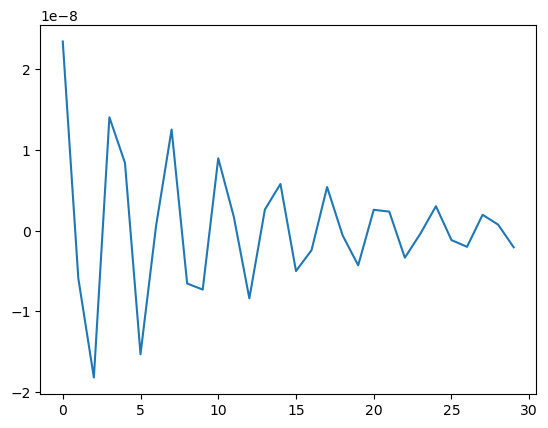

In [13]:
plt.plot(Cov[0])
plt.show()

In [7]:
cov_1ns = cov(150, 1e-9, A, omega0, gamma, p, C)

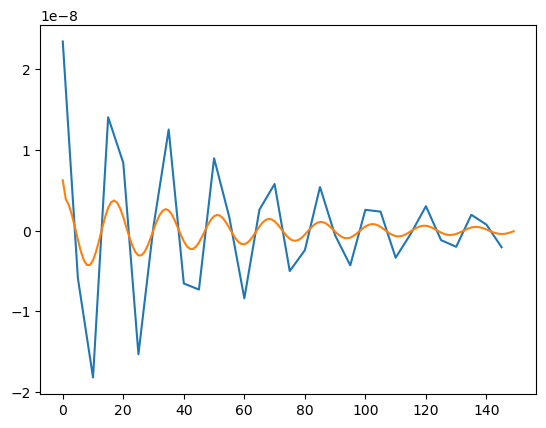

In [10]:
plt.plot(np.arange(30)*5,Cov[0])
plt.plot(cov_1ns[0])
plt.show()

In [11]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return toeplitz(cov0)

In [12]:
Cov = cov(30, A, omega0, gamma, p, C)

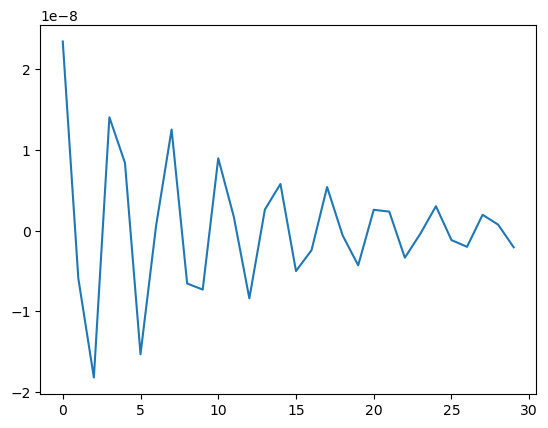

In [14]:
plt.plot(Cov[0])
plt.show()

In [26]:
seed = 45
key, subkey = random.split(random.PRNGKey(seed))

a = jft.NormalPrior(mean=0, std=1, shape=(30,), name="input")

xi = jft.random_like(subkey, a.domain)

In [ ]:
latent_sample = xi["input"]

In [ ]:
latent_sample

Array([ 1.9180208e-01,  1.7461933e+00,  1.1431401e+00,  9.5439911e-01,
       -9.5342153e-01, -3.7014183e-01,  3.2377115e-01, -1.3228760e+00,
        1.0857606e+00,  1.1462193e+00, -2.9842633e-01, -7.4605739e-01,
       -3.5558436e-02, -3.8187864e-01,  1.1191795e+00, -1.5680355e+00,
       -1.6446087e+00,  6.3437021e-01, -4.9469388e-01,  1.4544804e+00,
        3.8840330e-01,  9.7231662e-01, -8.2733959e-04, -6.8521619e-01,
       -1.3215718e+00,  7.4683768e-01,  5.9171343e-01,  7.2699022e-01,
        4.2041764e-01,  2.4844296e-01], dtype=float32)

In [35]:
a_sample = a(xi)

In [36]:
a_sample

Array([ 1.9180208e-01,  1.7461933e+00,  1.1431401e+00,  9.5439911e-01,
       -9.5342153e-01, -3.7014183e-01,  3.2377115e-01, -1.3228760e+00,
        1.0857606e+00,  1.1462193e+00, -2.9842633e-01, -7.4605739e-01,
       -3.5558436e-02, -3.8187864e-01,  1.1191795e+00, -1.5680355e+00,
       -1.6446087e+00,  6.3437021e-01, -4.9469388e-01,  1.4544804e+00,
        3.8840330e-01,  9.7231662e-01, -8.2733959e-04, -6.8521619e-01,
       -1.3215718e+00,  7.4683768e-01,  5.9171343e-01,  7.2699022e-01,
        4.2041764e-01,  2.4844296e-01], dtype=float32)

In [38]:
# Check if cov is PSD
eig = np.linalg.eigvalsh(Cov)
eig.min()

np.float64(1.630191586551743e-10)

In [43]:
L = np.linalg.cholesky(Cov)
n = L @ a_sample

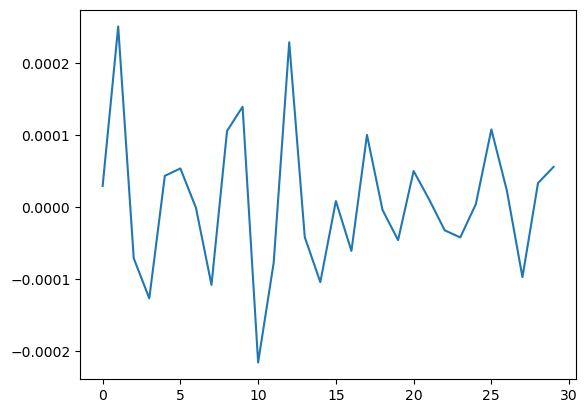

In [44]:
plt.plot(n)
plt.show()

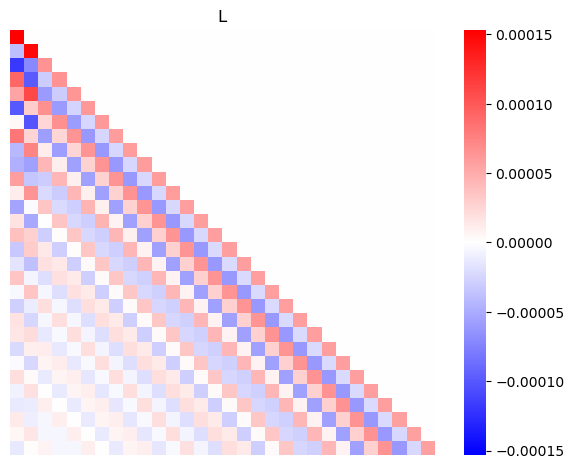

In [51]:
plt.figure()
sns.heatmap(L, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title(f"L")
plt.tight_layout()
plt.show()

In [45]:
L_1 = np.linalg.inv(L)

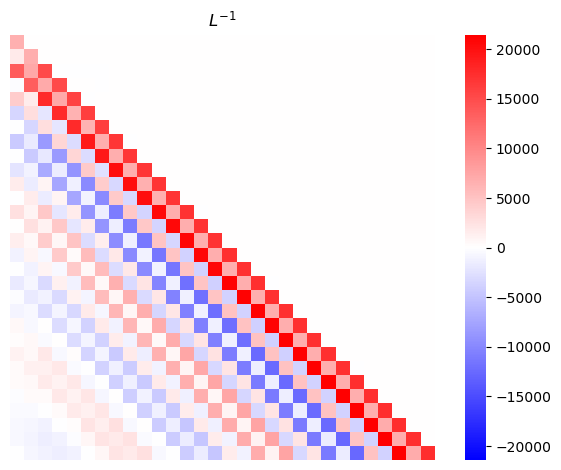

In [52]:
plt.figure()
sns.heatmap(L_1, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title(r"$L^{-1}$")
plt.tight_layout()
plt.show()

In [ ]:
z_rec = 